# Exploratory Data Analysis — E-Commerce Order Dataset
### Project 2 | DecodeLabs Data Analytics Internship Kit

**Goal:** Analyze the dataset to understand patterns, trends, and distributions — calculate basic statistics, identify trends and outliers, and summarize key observations.

**Dataset:** `Dataset_for_Data_Analytics.xlsx` — 1,200 e-commerce orders × 14 fields (Jan 2023 – Jun 2025).

**Framework:** Input → Process → Output (IPO), as covered in the training module — raw data is audited, statistically interrogated, then translated into business-relevant insight.


## 0. Setup

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', None)
plt.rcParams['font.family'] = 'DejaVu Sans'

NAVY, TEAL, ACCENT, GREY, GRID = '#1f3864', '#2c8c99', '#e67e22', '#595959', '#dddddd'

def style_ax(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', color=GRID, linewidth=0.7)
    ax.set_axisbelow(True)


In [ ]:
df = pd.read_excel('Dataset for Data Analytics.xlsx')
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df.Date.dt.year
df['Month'] = df.Date.dt.month
print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")
df.head()


Rows: 1,200 | Columns: 16


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Year,Month
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2023,1
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,2024,8
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2024,2
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,2023,10
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2025,5


## 1. Data Quality Audit

Before analyzing patterns, we treat the dataset as "digital evidence" — checking for missing values,
duplicates, and referential consistency (does `TotalPrice` actually equal `Quantity × UnitPrice`?).


In [3]:
print("Duplicate rows:", df.duplicated().sum())
print()
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Duplicate rows: 0

Missing values per column:
CouponCode    309
dtype: int64


In [4]:
# Referential integrity check: TotalPrice should equal Quantity * UnitPrice
calc = df.Quantity * df.UnitPrice
mismatches = (abs(calc - df.TotalPrice) > 0.5).sum()
print(f"TotalPrice calculation mismatches: {mismatches} / {len(df)}")

# Confirm CouponCode nulls are legitimate ("no coupon used"), not a data gap
print(f"\nCouponCode nulls: {df.CouponCode.isnull().sum()} ({df.CouponCode.isnull().mean():.1%} of orders)")
print("CouponCode value counts (incl. nulls):")
print(df.CouponCode.value_counts(dropna=False))


TotalPrice calculation mismatches: 0 / 1200

CouponCode nulls: 309 (25.8% of orders)
CouponCode value counts (incl. nulls):
CouponCode
FREESHIP    313
NaN         309
WINTER15    292
SAVE10      286
Name: count, dtype: int64


**Finding:** No duplicate orders. `TotalPrice` reconciles exactly with `Quantity × UnitPrice` on every row —
the source system's calculation logic is sound. The only "missing" field is `CouponCode`, which is legitimately
blank for the 309 orders (25.8%) that used no coupon. Effective data completeness is 100%.

## 2. Descriptive Statistics — Central Tendency & Spread

Calculating mean, median, and the full five-number summary for every numeric field.


In [5]:
numeric_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']
df[numeric_cols].describe().round(2)


,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.00,1200.00,1200.00,1200.00
mean,2.95,356.41,5.48,1053.97
std,1.41,197.18,2.28,819.86
min,1.00,11.39,1.00,11.39
25%,2.00,186.06,4.00,410.52
50%,3.00,364.21,5.00,823.62
75%,4.00,521.57,7.00,1578.48
max,5.00,699.93,10.00,3456.40


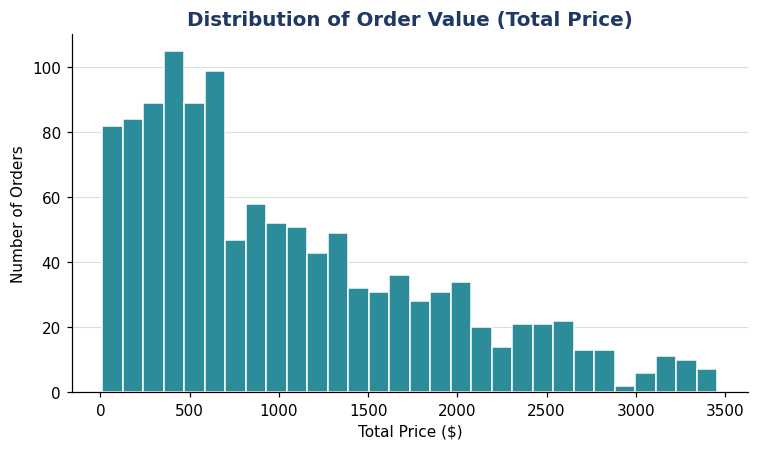

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.2), dpi=110)
ax.hist(df.TotalPrice, bins=30, color=TEAL, edgecolor='white')
ax.set_title('Distribution of Order Value (Total Price)', fontsize=13, fontweight='bold', color=NAVY)
ax.set_xlabel('Total Price ($)')
ax.set_ylabel('Number of Orders')
style_ax(ax)
plt.tight_layout()
plt.show()


**Finding:** Mean order value ($1,053.97) is noticeably higher than the median ($823.62) — the distribution
is right-skewed. This is the classic "Elon Musk in the room" effect: a handful of high-value orders pull the
average upward. For reporting a *typical* order to stakeholders, the **median is the more honest metric**.

## 3. Outlier Analysis (IQR Method)

Using the standard 1.5×IQR fence: values below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR` are flagged.


In [7]:
def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return mask, lower, upper

for col in numeric_cols:
    mask, lower, upper = iqr_outliers(df[col])
    print(f"{col:12s}: {mask.sum()} outliers | bounds=({lower:.2f}, {upper:.2f})")


Quantity    : 0 outliers | bounds=(-1.00, 7.00)
UnitPrice   : 0 outliers | bounds=(-317.20, 1024.83)
ItemsInCart : 0 outliers | bounds=(-0.50, 11.50)
TotalPrice  : 8 outliers | bounds=(-1341.41, 3330.41)


In [8]:
mask, lower, upper = iqr_outliers(df.TotalPrice)
outliers = df.loc[mask, ['OrderID','Product','Quantity','UnitPrice','TotalPrice','OrderStatus']]
outliers.sort_values('TotalPrice', ascending=False)


,OrderID,Product,Quantity,UnitPrice,TotalPrice,OrderStatus
789,ORD200789,Tablet,5,691.28,3456.40,Delivered
1122,ORD201122,Monitor,5,678.19,3390.95,Returned
632,ORD200632,Laptop,5,678.16,3390.80,Delivered
469,ORD200469,Chair,5,676.98,3384.90,Cancelled
328,ORD200328,Tablet,5,674.04,3370.20,Cancelled
107,ORD200107,Printer,5,670.75,3353.75,Shipped
326,ORD200326,Laptop,5,670.48,3352.40,Returned
1065,ORD201065,Printer,5,666.80,3334.00,Delivered


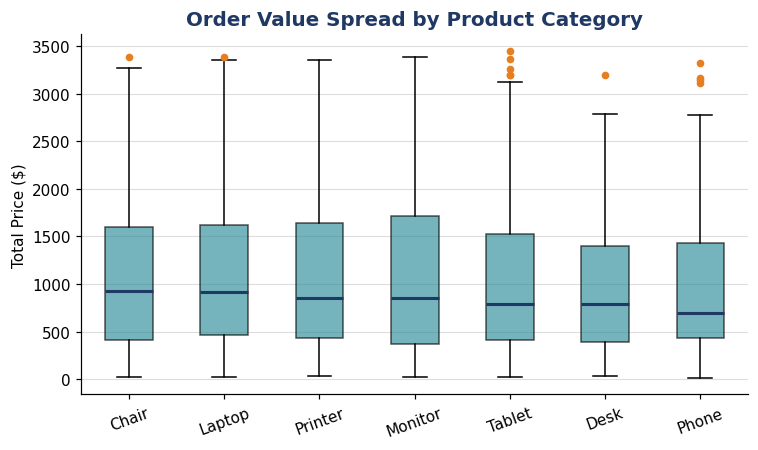

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.2), dpi=110)
products = df.groupby('Product').TotalPrice.median().sort_values(ascending=False).index
data = [df[df.Product == p].TotalPrice.values for p in products]
bp = ax.boxplot(data, tick_labels=products, patch_artist=True,
                 flierprops=dict(marker='o', markerfacecolor=ACCENT, markersize=4, markeredgecolor=ACCENT))
for box in bp['boxes']:
    box.set_facecolor(TEAL); box.set_alpha(0.65)
for med in bp['medians']:
    med.set_color(NAVY); med.set_linewidth(2)
ax.set_title('Order Value Spread by Product Category', fontsize=13, fontweight='bold', color=NAVY)
ax.set_ylabel('Total Price ($)')
plt.xticks(rotation=20)
style_ax(ax)
plt.tight_layout()
plt.show()


**Finding — Signal, not Noise:** All 8 outliers are maximum-quantity (5-unit) orders of premium-priced items.
This is a coherent, explainable pattern rather than a data-entry error — these are DecodeLabs' highest-value
transactions and should be flagged for VIP/bulk-buyer treatment, not cleaned out.

## 4. Correlation Analysis

Mapping relationships between the numeric fields using the Pearson correlation coefficient.


In [10]:
corr = df[numeric_cols].corr()
corr.round(3)


,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.000,0.015,0.650,0.615
UnitPrice,0.015,1.000,0.001,0.717
ItemsInCart,0.650,0.001,1.000,0.393
TotalPrice,0.615,0.717,0.393,1.000


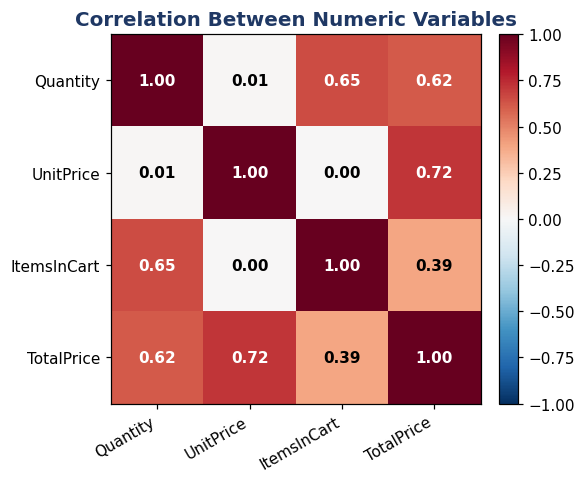

In [11]:
fig, ax = plt.subplots(figsize=(5.5, 4.5), dpi=110)
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=30, ha='right')
ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center',
                 color='white' if abs(corr.iloc[i,j]) > 0.5 else 'black', fontsize=10, fontweight='bold')
ax.set_title('Correlation Between Numeric Variables', fontsize=13, fontweight='bold', color=NAVY)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


**Finding:** `UnitPrice` (r = 0.72) is the strongest driver of `TotalPrice`, ahead of `Quantity` (r = 0.62).
`Quantity` and `ItemsInCart` correlate at r = 0.65, suggesting genuine bulk-purchase behavior.

> **Golden Rule reminder:** correlation ≠ causation. `UnitPrice` and `TotalPrice` move together partly by
> construction (`TotalPrice` is a direct function of `UnitPrice`), so this mainly confirms the calculation
> logic rather than revealing new behavior.

## 5. Categorical & Trend Analysis

### 5.1 Revenue by Product Category

In [12]:
rev_by_product = df.groupby('Product').TotalPrice.agg(['count','sum','mean']).round(2).sort_values('sum', ascending=False)
rev_by_product.columns = ['Orders','Revenue ($)','Avg Order Value ($)']
rev_by_product


,Orders,Revenue ($),Avg Order Value ($)
Product,,,
Chair,178,195620.11,1098.99
Printer,181,195612.61,1080.73
Laptop,173,192126.56,1110.56
Tablet,179,186568.95,1042.28
Monitor,163,175651.41,1077.62
Desk,170,167459.93,985.06
Phone,156,151722.39,972.58


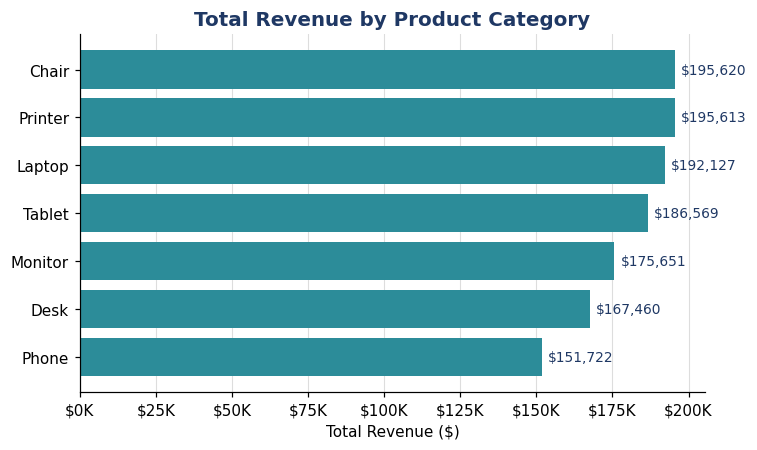

In [13]:
fig, ax = plt.subplots(figsize=(7, 4.2), dpi=110)
rev = df.groupby('Product').TotalPrice.sum().sort_values()
bars = ax.barh(rev.index, rev.values, color=TEAL)
ax.set_title('Total Revenue by Product Category', fontsize=13, fontweight='bold', color=NAVY)
ax.set_xlabel('Total Revenue ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
style_ax(ax); ax.grid(axis='x', color=GRID, linewidth=0.7); ax.grid(axis='y', visible=False)
for b in bars:
    w = b.get_width()
    ax.text(w + 2000, b.get_y() + b.get_height()/2, f'${w:,.0f}', va='center', fontsize=9, color=NAVY)
plt.tight_layout()
plt.show()


### 5.2 Order Fulfillment Health

In [14]:
status_counts = df.OrderStatus.value_counts()
cancel_return_rate = df.OrderStatus.isin(['Cancelled','Returned']).mean()
print(status_counts)
print(f"\nCancelled + Returned rate: {cancel_return_rate:.1%}")


OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

Cancelled + Returned rate: 41.4%


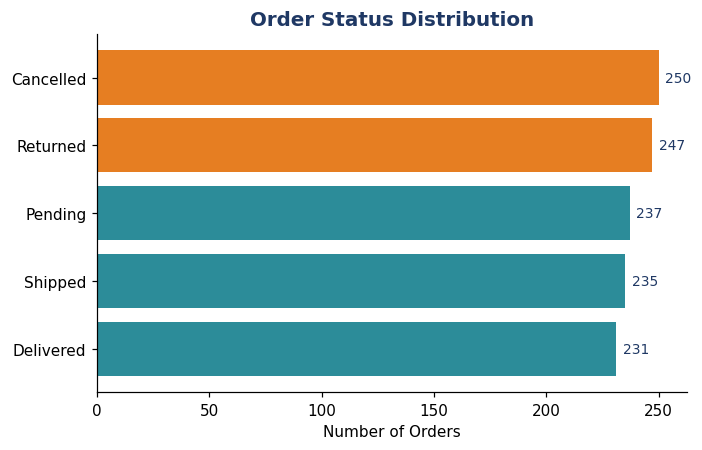

In [15]:
fig, ax = plt.subplots(figsize=(6.5, 4.2), dpi=110)
status = df.OrderStatus.value_counts().sort_values()
colors = [ACCENT if s in ['Cancelled','Returned'] else TEAL for s in status.index]
bars = ax.barh(status.index, status.values, color=colors)
ax.set_title('Order Status Distribution', fontsize=13, fontweight='bold', color=NAVY)
ax.set_xlabel('Number of Orders')
style_ax(ax); ax.grid(axis='y', visible=False)
for b in bars:
    w = b.get_width()
    ax.text(w + 3, b.get_y() + b.get_height()/2, f'{int(w)}', va='center', fontsize=9, color=NAVY)
plt.tight_layout()
plt.show()


**Finding — most business-critical result in the dataset:** 41.4% of orders end in Cancelled or Returned
status. Cancelled orders alone represent $276,396 — more revenue than any single product category generates.

### 5.3 Order Volume Trend

In [16]:
# Naive monthly counts (all years combined) can mislead, since 2025 only has data through June
naive_monthly = df.groupby('Month').OrderID.count()
print("Naive monthly counts (all years, biased by partial 2025):")
print(naive_monthly)

# Corrected: use complete years only (2023-2024)
full_years = df[df.Year.isin([2023, 2024])]
corrected_monthly = full_years.groupby('Month').OrderID.count()
print("\nCorrected monthly counts (2023-2024 full years only):")
print(corrected_monthly)


Naive monthly counts (all years, biased by partial 2025):
Month
1     106
2     106
3     128
4     113
5     120
6     147
7      87
8      79
9      73
10     78
11     76
12     87
Name: OrderID, dtype: int64

Corrected monthly counts (2023-2024 full years only):
Month
1     79
2     69
3     79
4     81
5     83
6     98
7     87
8     79
9     73
10    78
11    76
12    87
Name: OrderID, dtype: int64


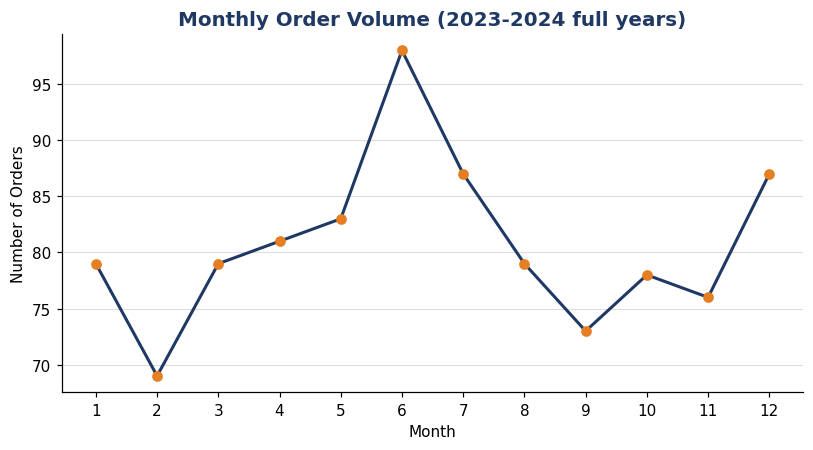

In [17]:
fig, ax = plt.subplots(figsize=(7.5, 4.2), dpi=110)
ax.plot(corrected_monthly.index, corrected_monthly.values, marker='o', color=NAVY, linewidth=2,
        markerfacecolor=ACCENT, markeredgecolor=ACCENT, markersize=6)
ax.set_title('Monthly Order Volume (2023-2024 full years)', fontsize=13, fontweight='bold', color=NAVY)
ax.set_xlabel('Month'); ax.set_ylabel('Number of Orders')
ax.set_xticks(range(1, 13))
style_ax(ax)
plt.tight_layout()
plt.show()


**Finding:** The raw combined-year view suggested a June peak and a second-half decline — but that's an
artifact of 2025 data stopping at June 30 and overweighting those months. Restricted to complete years
(2023–2024), order volume is fairly stable year-round, with only a mild September dip.

### 5.4 Payment Method & Referral Source

In [18]:
df.groupby('PaymentMethod').TotalPrice.agg(['count','sum','mean']).round(2)


,count,sum,mean
PaymentMethod,,,
Cash,246,259786.29,1056.04
Credit Card,234,263847.63,1127.55
Debit Card,232,232361.18,1001.56
Gift Card,230,246323.92,1070.97
Online,258,262442.94,1017.22


In [19]:
df.groupby('ReferralSource').TotalPrice.agg(['count','sum','mean']).round(2).sort_values('sum', ascending=False)


,count,sum,mean
ReferralSource,,,
Instagram,259,275285.45,1062.88
Email,250,261808.55,1047.23
Google,241,250441.48,1039.18
Facebook,228,250410.90,1098.29
Referral,222,226815.58,1021.69


### 5.5 Coupon Usage Effect

In [20]:
df['HasCoupon'] = df.CouponCode.notna()
df.groupby('HasCoupon').TotalPrice.agg(['count','mean']).round(2)


,count,mean
HasCoupon,,
False,309,1043.37
True,891,1057.64


**Finding:** Orders with a coupon applied average $1,057.64 vs. $1,043.37 without — essentially no
difference. Coupons in this dataset are not measurably increasing basket size.

## 6. Business Impact — Translating Findings into Action

| What the Data Shows | Business Diagnosis |
|---|---|
| 41.4% of orders are Cancelled or Returned | ~$519K in at-risk revenue — larger than any single product line's total revenue. Highest-priority issue to root-cause. |
| TotalPrice is right-skewed (mean $1,053.97 vs. median $823.62) | Standard "average order value" reporting overstates typical spend by ~28%. Use the median for stakeholder reporting. |
| 8 orders are 5-unit, premium-price bulk purchases | DecodeLabs' highest-value transactions, not noise — candidates for a VIP/bulk-buyer segment. |
| UnitPrice (r=0.72) outweighs Quantity (r=0.62) as a revenue driver | Upselling to higher-priced SKUs is likely more effective than promoting larger cart sizes. |
| Order volume is stable, not seasonal, once corrected for partial-year data | No urgent need for seasonal staffing/inventory swings. |


## 7. Recommendations & Conclusion

**Recommendations**
1. Investigate cancellation/return drivers first — the largest source of revenue leakage found here.
2. Report order value using the median (or both mean and median) to avoid overstating typical spend.
3. Flag 5-unit, premium-price orders for a dedicated bulk-buyer / VIP retention track.
4. Prioritize upsell campaigns toward higher-priced product tiers over cart-size promotions.
5. Re-evaluate coupon strategy against conversion data rather than basket size, since it shows no AOV lift.

**Conclusion**

The dataset is clean, internally consistent, and ready for deeper analysis or dashboarding. The dominant
diagnostic finding — a 41.4% cancellation/return rate — outweighs any single product or channel insight and
should anchor the next phase of investigation. Fulfillment reliability, not product mix or marketing channel,
is the primary constraint on DecodeLabs' realized revenue.
